# Binary routing classifier v1

Predict whether `routing_label` is **target** (1) or **other** (0) from `article_text`.

**Pipeline:** TF-IDF + Logistic Regression (no model selection in v1).

**Evaluation layers:**
- **Layer A** — always predict (model quality): F1 / ROC / PR on all holdout rows
- **Layer B** — abstain band (routing): coverage + metrics on auto-routed subset only


## 1. Setup

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    roc_curve,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [3]:
def resolve_data_path(filename: str = "synthetic_topic_articles_v4.csv") -> Path:
    """Find data file whether the kernel cwd is project root or notebooks/."""
    candidates = [
        Path.cwd() / "data" / filename,
        Path.cwd() / "../data" / filename,
        Path.cwd().parent / "data" / filename,
    ]
    for path in candidates:
        if path.resolve().exists():
            return path.resolve()
    raise FileNotFoundError(
        f"Could not find {filename}. Tried:\n" + "\n".join(str(p.resolve()) for p in candidates)
    )

DATA_PATH = resolve_data_path()
print("Loading:", DATA_PATH)

Loading: /Users/jianchenyang/Documents/projects/file_topic_routing/data/synthetic_topic_articles_v4.csv


## 2. Load and label

In [6]:
df = pd.read_csv(DATA_PATH)
df["y"] = (df["routing_label"] == "target").astype(int)

print("shape:", df.shape)
print("nulls:", df[["article_text", "routing_label"]].isna().sum().to_dict())
print("\nlabel balance:")
print(df["routing_label"].value_counts())
print(df["y"].value_counts(normalize=True).rename("fraction"))

shape: (200, 13)
nulls: {'article_text': 0, 'routing_label': 0}

label balance:
routing_label
other     130
target     70
Name: count, dtype: int64
y
0    0.65
1    0.35
Name: fraction, dtype: float64


## 3. Stratified train / test split

Holdout is used **once** for final Layer A / B reports. All CV and tuning stay on train.

In [13]:
X = df["article_text"]
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"train: {len(X_train)}  test: {len(X_test)}")
print("train pos rate:", y_train.mean().round(3))
print("test  pos rate:", y_test.mean().round(3))

train: 160  test: 40
train pos rate: 0.35
test  pos rate: 0.35


## 4. Pipeline + hyperparameter tuning (F1)

Single model family: TF-IDF → LogisticRegression. Grid search with stratified 5-fold CV on train only.

In [15]:
pipe = Pipeline(
    [
        ("tfidf", TfidfVectorizer(sublinear_tf=True)),
        (
            "clf",
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                solver="liblinear",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

param_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2],
    "tfidf__max_features": [5000, 10000, None],
    "clf__C": [0.1, 1.0, 10.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = GridSearchCV(
    pipe,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1,
)

search.fit(X_train, y_train)
best_model = search.best_estimator_

print("best CV F1:", round(search.best_score_, 4))
print("best params:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
best CV F1: 0.655
best params:
  clf__C: 10.0
  tfidf__max_features: 5000
  tfidf__min_df: 1
  tfidf__ngram_range: (1, 1)


### GridSearchCV results (visualization)

Post-hoc view of CV F1 across the grid. Useful to see winners and fold noise; does not change the selected `best_model`.


top 10 configs by mean CV F1:


,mean_test_score,std_test_score,param_label
0,0.654977,0.177497,"C=10.0, max_features=None, min_df=1, ngram_ran..."
1,0.654977,0.177497,"C=10.0, max_features=10000, min_df=1, ngram_ra..."
2,0.654977,0.177497,"C=10.0, max_features=5000, min_df=1, ngram_ran..."
3,0.615842,0.103482,"C=10.0, max_features=None, min_df=2, ngram_ran..."
4,0.615842,0.103482,"C=10.0, max_features=10000, min_df=2, ngram_ra..."
5,0.615842,0.103482,"C=10.0, max_features=5000, min_df=2, ngram_ran..."
6,0.549713,0.144942,"C=10.0, max_features=None, min_df=1, ngram_ran..."
7,0.549713,0.144942,"C=10.0, max_features=10000, min_df=1, ngram_ra..."
8,0.549713,0.144942,"C=10.0, max_features=5000, min_df=1, ngram_ran..."
9,0.513928,0.116694,"C=10.0, max_features=None, min_df=2, ngram_ran..."


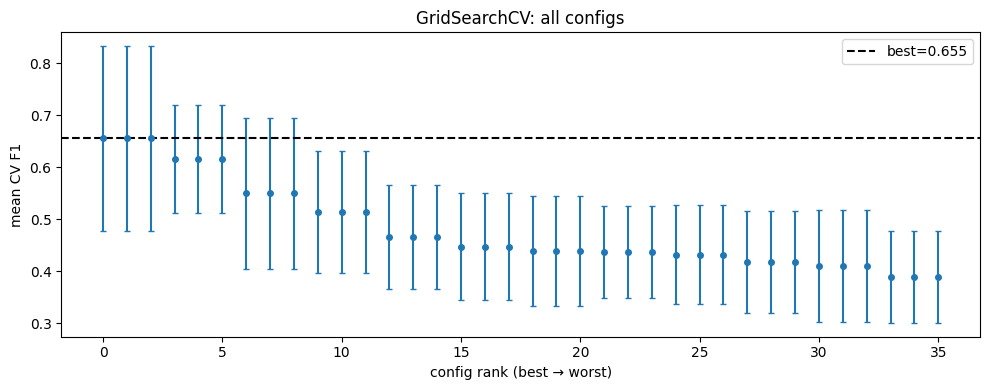

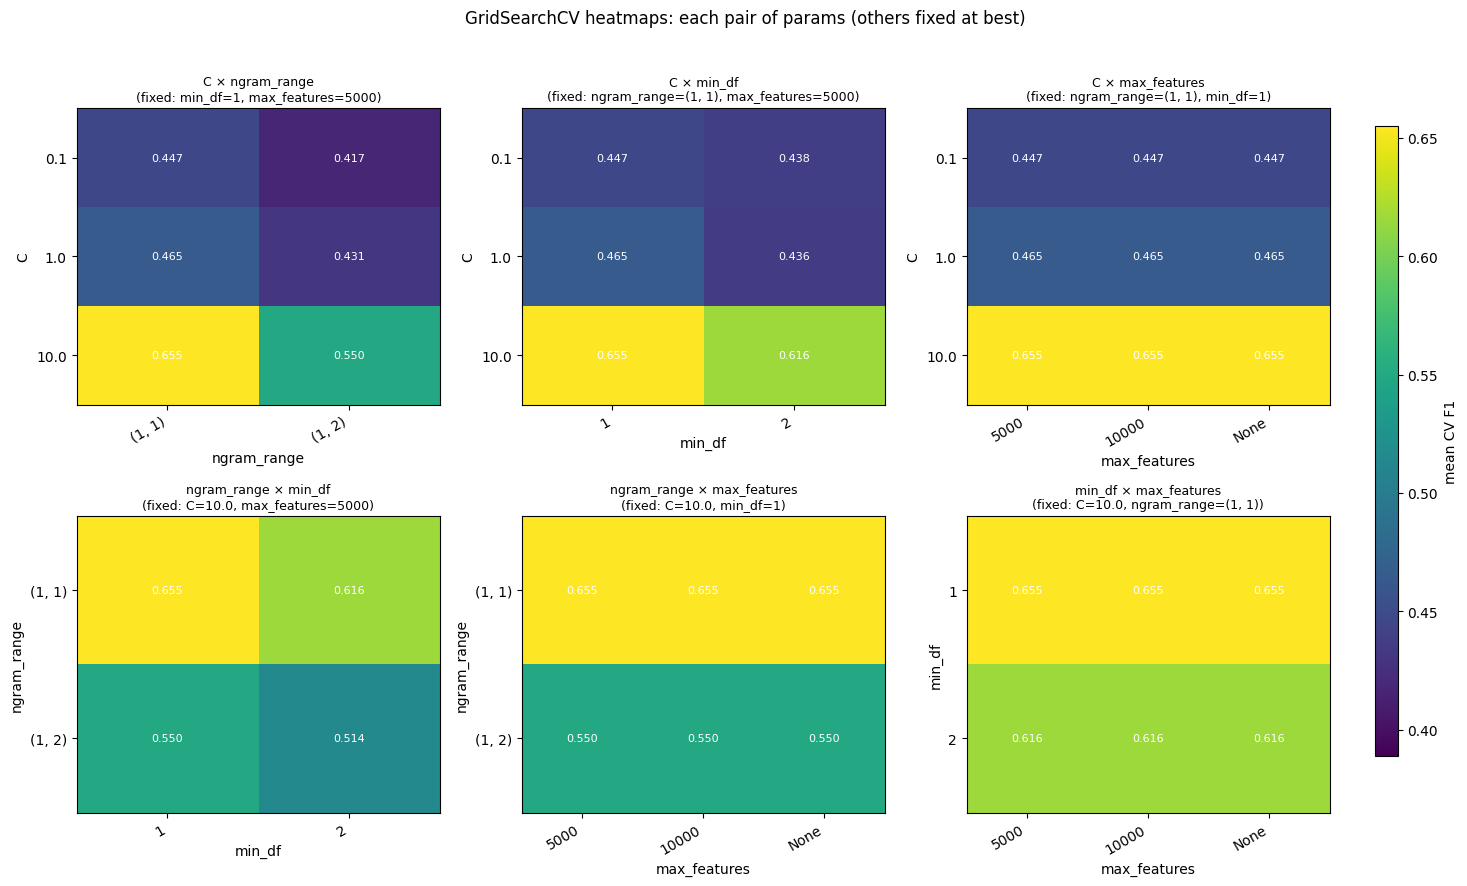

In [80]:
from itertools import combinations

PARAM_KEYS = [
    "clf__C",
    "tfidf__ngram_range",
    "tfidf__min_df",
    "tfidf__max_features",
]

cv_results = pd.DataFrame(search.cv_results_).sort_values(
    "mean_test_score", ascending=False
).reset_index(drop=True)

cv_results["param_label"] = cv_results["params"].apply(
    lambda d: ", ".join(f"{k.split('__')[-1]}={v}" for k, v in d.items())
)

print("top 10 configs by mean CV F1:")
display(
    cv_results.loc[:9, ["mean_test_score", "std_test_score", "param_label"]]
)

# --- Figure 1: ranked CV scores ---
fig1, ax1 = plt.subplots(figsize=(10, 4))
ax1.errorbar(
    cv_results.index,
    cv_results["mean_test_score"],
    yerr=cv_results["std_test_score"],
    fmt="o",
    markersize=4,
    capsize=2,
)
ax1.axhline(
    search.best_score_, color="black", linestyle="--", label=f"best={search.best_score_:.3f}"
)
ax1.set_xlabel("config rank (best → worst)")
ax1.set_ylabel("mean CV F1")
ax1.set_title("GridSearchCV: all configs")
ax1.legend()
fig1.tight_layout()
plt.show()

# --- Figure 2: 6 heatmaps (C(4,2) param pairs; others fixed at best) ---
best = search.best_params_


def _short(name):
    return name.split("__")[-1]


def _fmt(v):
    return "None" if v is None else str(v)


def _grid_order(key):
    """Preserve grid order; read values from params dict (handles None cleanly)."""
    vals = []
    for p in search.cv_results_["params"]:
        v = p[key]
        if v not in vals:
            vals.append(v)
    return vals


def _filter_fixed(df, fixed: dict):
    return df[df["params"].apply(lambda p: all(p.get(k) == v for k, v in fixed.items()))]


fig2, axes = plt.subplots(2, 3, figsize=(15, 9))
pair_list = list(combinations(PARAM_KEYS, 2))
vmin = cv_results["mean_test_score"].min()
vmax = cv_results["mean_test_score"].max()

for ax, (row_key, col_key) in zip(axes.ravel(), pair_list):
    fixed_keys = [k for k in PARAM_KEYS if k not in (row_key, col_key)]
    fixed = {k: best[k] for k in fixed_keys}
    sub = _filter_fixed(cv_results, fixed).copy()

    row_order = _grid_order(row_key)
    col_order = _grid_order(col_key)
    sub["_row"] = sub["params"].apply(lambda p: _fmt(p[row_key]))
    sub["_col"] = sub["params"].apply(lambda p: _fmt(p[col_key]))
    pivot = sub.pivot_table(
        index="_row",
        columns="_col",
        values="mean_test_score",
        aggfunc="first",
    ).reindex(
        index=[_fmt(v) for v in row_order],
        columns=[_fmt(v) for v in col_order],
    )

    im = ax.imshow(
        pivot.values.astype(float),
        aspect="auto",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(list(pivot.columns), rotation=30, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(list(pivot.index))
    ax.set_xlabel(_short(col_key))
    ax.set_ylabel(_short(row_key))
    fixed_txt = ", ".join(f"{_short(k)}={_fmt(best[k])}" for k in fixed_keys)
    ax.set_title(f"{_short(row_key)} × {_short(col_key)}\n(fixed: {fixed_txt})", fontsize=9)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if val == val:
                ax.text(j, i, f"{float(val):.3f}", ha="center", va="center", color="white", fontsize=8)

fig2.suptitle("GridSearchCV heatmaps: each pair of params (others fixed at best)")
# reserve right margin, then place a dedicated colorbar axis (avoids overlapping subplots)
fig2.tight_layout(rect=[0, 0, 0.90, 0.96])
cax = fig2.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height] in figure coords
fig2.colorbar(im, cax=cax, label="mean CV F1")
plt.show()


## 5. Layer A — always predict (model quality)

Every test row gets Target or Other.

**Operating-point note:** the default / reported threshold for Layer A is **0.5**.
Subsections (2)–(4) are **analytics only** — they show how train-derived cutoffs would look on test, but they do **not** drive a production threshold change in v1.


### (1) Default threshold 0.5

Headline Layer A report.


=== Layer A (1) @ threshold 0.5 ===
              precision    recall  f1-score   support

       other       0.92      0.85      0.88        26
      target       0.75      0.86      0.80        14

    accuracy                           0.85        40
   macro avg       0.83      0.85      0.84        40
weighted avg       0.86      0.85      0.85        40

ROC-AUC: 0.9451
PR-AUC : 0.911


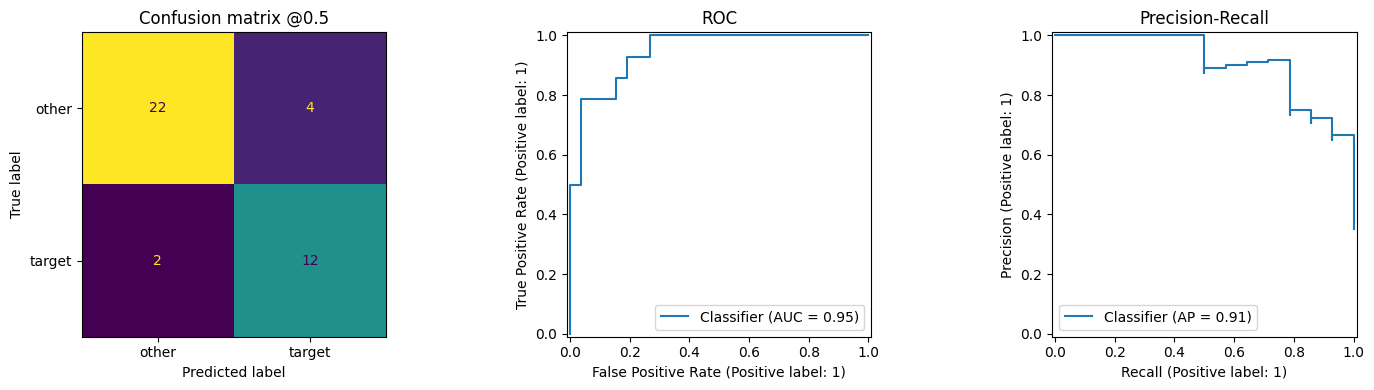

In [60]:
proba_test = best_model.predict_proba(X_test)[:, 1]
proba_train = best_model.predict_proba(X_train)[:, 1]
y_pred_05 = (proba_test >= 0.5).astype(int)

print("=== Layer A (1) @ threshold 0.5 ===")
print(classification_report(y_test, y_pred_05, target_names=["other", "target"]))
print("ROC-AUC:", round(roc_auc_score(y_test, proba_test), 4))
print("PR-AUC :", round(average_precision_score(y_test, proba_test), 4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_05),
    display_labels=["other", "target"],
).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion matrix @0.5")

RocCurveDisplay.from_predictions(y_test, proba_test, ax=axes[1])
axes[1].set_title("ROC")

PrecisionRecallDisplay.from_predictions(y_test, proba_test, ax=axes[2])
axes[2].set_title("Precision-Recall")

plt.tight_layout()
plt.show()


### Better than chance? — baseline comparison

Compare the fitted model to simple **label-only** baselines that **ignore `article_text`**:

| name | what it does |
|---|---|
| **TF-IDF + LR** | learns from article text |
| **Always majority class** | every row → most common **train** label (deterministic) |
| **Random w/ train rates** | each row randomly Target/Other with **train** class frequencies |
| **Coin flip 50/50** | each row fair coin; ignores train imbalance |

Majority ≠ random-with-rates even for 2 classes: one always picks the same label; the other still emits both classes at random.

If TF-IDF + LR beats these on the **same test set**, the model is using the text (not just label prevalence).


In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

def eval_binary(name, y_true, y_hat, y_score):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_hat),
        "precision": precision_score(y_true, y_hat, zero_division=0),
        "recall": recall_score(y_true, y_hat, zero_division=0),
        "f1": f1_score(y_true, y_hat, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
    }

MODEL_NAME = "TF-IDF + LR (tuned)"
baseline_rows = [
    eval_binary(MODEL_NAME, y_test, y_pred_05, proba_test),
]

# (display name, DummyClassifier strategy, short legend label for plot)
dummy_specs = [
    (
        "Always majority class",
        "most_frequent",
        "Always majority\n(every row = train mode)",
    ),
    (
        "Random w/ train rates",
        "stratified",
        "Random w/ train rates\n(draw each row from prior)",
    ),
    (
        "Coin flip 50/50",
        "uniform",
        "Coin flip 50/50\n(ignore train mix)",
    ),
]

legend_labels = {MODEL_NAME: "TF-IDF + LR\n(learned from text)"}
for name, strategy, legend in dummy_specs:
    dummy = DummyClassifier(strategy=strategy, random_state=RANDOM_STATE)
    dummy.fit(X_train, y_train)  # X ignored; learns label prior only
    y_hat = dummy.predict(X_test)
    y_score = dummy.predict_proba(X_test)[:, 1]
    baseline_rows.append(eval_binary(name, y_test, y_hat, y_score))
    legend_labels[name] = legend

baseline_cmp = pd.DataFrame(baseline_rows).set_index("model")
display(baseline_cmp.round(4))

best_dummy_f1 = baseline_cmp.drop(index=MODEL_NAME)["f1"].max()
model_f1 = baseline_cmp.loc[MODEL_NAME, "f1"]
print(
    f"\nF1 lift vs best label-only baseline: {model_f1 - best_dummy_f1:+.4f}  "
    f"(model={model_f1:.4f}, best_baseline={best_dummy_f1:.4f})"
)

plot_metrics = ["accuracy", "f1", "roc_auc", "pr_auc"]
plot_df = baseline_cmp[plot_metrics]

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(plot_metrics))
width = 0.2
for i, (model_name, row) in enumerate(plot_df.iterrows()):
    ax.bar(x + i * width, row.values, width, label=legend_labels[model_name])
ax.set_xticks(x + width * (len(plot_df) - 1) / 2)
ax.set_xticklabels(plot_metrics)
ax.set_ylim(0, 1.05)
ax.set_ylabel("score")
ax.set_title("Model vs label-only baselines (same test set)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9)
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1)
plt.tight_layout()
plt.show()


### (2) Train F1 sweep (analytics)

Pick `t` that maximizes **train** F1, then score test. Not used to change the default threshold.


train-best F1 threshold: 0.440
train F1 @ that threshold: 0.9825

=== Layer A (2) @ train-F1 threshold 0.440 (test) ===
              precision    recall  f1-score   support

       other       1.00      0.73      0.84        26
      target       0.67      1.00      0.80        14

    accuracy                           0.82        40
   macro avg       0.83      0.87      0.82        40
weighted avg       0.88      0.82      0.83        40



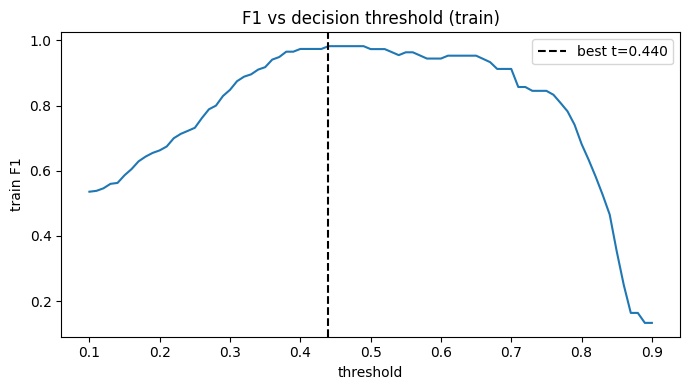

In [62]:
thresholds = np.linspace(0.1, 0.9, 81)
f1s_train = [f1_score(y_train, (proba_train >= t).astype(int)) for t in thresholds]
best_t_f1 = float(thresholds[int(np.argmax(f1s_train))])
y_pred_f1 = (proba_test >= best_t_f1).astype(int)

print(f"train-best F1 threshold: {best_t_f1:.3f}")
print(f"train F1 @ that threshold: {max(f1s_train):.4f}")
print(f"\n=== Layer A (2) @ train-F1 threshold {best_t_f1:.3f} (test) ===")
print(classification_report(y_test, y_pred_f1, target_names=["other", "target"]))

plt.figure(figsize=(7, 4))
plt.plot(thresholds, f1s_train)
plt.axvline(best_t_f1, color="black", linestyle="--", label=f"best t={best_t_f1:.3f}")
plt.xlabel("threshold")
plt.ylabel("train F1")
plt.title("F1 vs decision threshold (train)")
plt.legend()
plt.tight_layout()
plt.show()


### (3) Youden's J on train ROC (analytics)

Maximize `J = TPR - FPR` on **train**, then score test. Analytics only.


train Youden threshold: 0.496
train J=TPR-FPR: 0.9808  (TPR=1.000, FPR=0.019)

=== Layer A (3) @ Youden threshold 0.496 (test) ===
              precision    recall  f1-score   support

       other       0.92      0.85      0.88        26
      target       0.75      0.86      0.80        14

    accuracy                           0.85        40
   macro avg       0.83      0.85      0.84        40
weighted avg       0.86      0.85      0.85        40



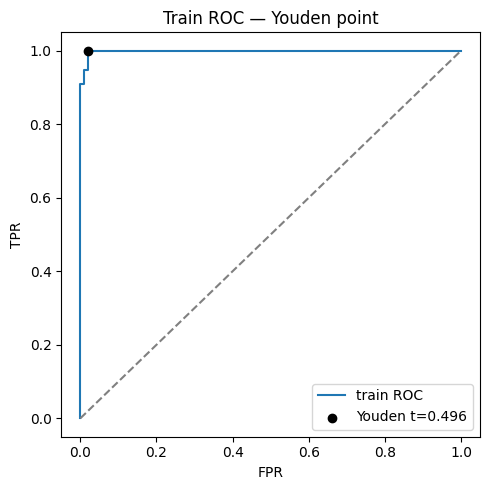

In [64]:
from sklearn.metrics import roc_curve

fpr_tr, tpr_tr, thr_roc = roc_curve(y_train, proba_train)
j = tpr_tr - fpr_tr
best_idx_j = int(np.argmax(j))
best_t_youden = float(thr_roc[best_idx_j])
# sklearn can return inf for the first threshold
if not np.isfinite(best_t_youden):
    best_t_youden = 1.0

y_pred_youden = (proba_test >= best_t_youden).astype(int)

print(f"train Youden threshold: {best_t_youden:.3f}")
print(f"train J=TPR-FPR: {j[best_idx_j]:.4f}  (TPR={tpr_tr[best_idx_j]:.3f}, FPR={fpr_tr[best_idx_j]:.3f})")
print(f"\n=== Layer A (3) @ Youden threshold {best_t_youden:.3f} (test) ===")
print(classification_report(y_test, y_pred_youden, target_names=["other", "target"]))

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr_tr, tpr_tr, label="train ROC")
ax.scatter(
    [fpr_tr[best_idx_j]], [tpr_tr[best_idx_j]],
    color="black", zorder=5,
    label=f"Youden t={best_t_youden:.3f}",
)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title("Train ROC — Youden point")
ax.legend()
plt.tight_layout()
plt.show()


### (4) Closest to top-left (0, 1) on train ROC (analytics)

Minimize distance to `(FPR=0, TPR=1)` on **train**, then score test. Analytics only.


train top-left threshold: 0.496
train distance to (0,1): 0.0192  (TPR=1.000, FPR=0.019)

=== Layer A (4) @ top-left threshold 0.496 (test) ===
              precision    recall  f1-score   support

       other       0.92      0.85      0.88        26
      target       0.75      0.86      0.80        14

    accuracy                           0.85        40
   macro avg       0.83      0.85      0.84        40
weighted avg       0.86      0.85      0.85        40



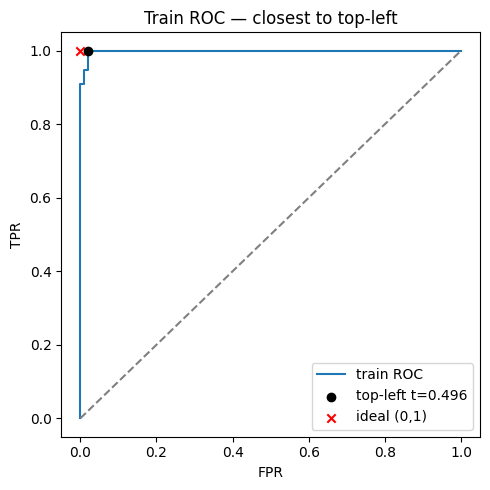

In [66]:
from sklearn.metrics import roc_curve

fpr_tl, tpr_tl, thr_tl = roc_curve(y_train, proba_train)
dist = np.sqrt(fpr_tl ** 2 + (1 - tpr_tl) ** 2)
best_idx_tl = int(np.argmin(dist))
best_t_topleft = float(thr_tl[best_idx_tl])
if not np.isfinite(best_t_topleft):
    best_t_topleft = 1.0

y_pred_topleft = (proba_test >= best_t_topleft).astype(int)

print(f"train top-left threshold: {best_t_topleft:.3f}")
print(
    f"train distance to (0,1): {dist[best_idx_tl]:.4f}  "
    f"(TPR={tpr_tl[best_idx_tl]:.3f}, FPR={fpr_tl[best_idx_tl]:.3f})"
)
print(f"\n=== Layer A (4) @ top-left threshold {best_t_topleft:.3f} (test) ===")
print(classification_report(y_test, y_pred_topleft, target_names=["other", "target"]))

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr_tl, tpr_tl, label="train ROC")
ax.scatter(
    [fpr_tl[best_idx_tl]], [tpr_tl[best_idx_tl]],
    color="black", zorder=5,
    label=f"top-left t={best_t_topleft:.3f}",
)
ax.scatter([0], [1], marker="x", color="red", label="ideal (0,1)")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title("Train ROC — closest to top-left")
ax.legend()
plt.tight_layout()
plt.show()


### Layer A threshold comparison (analytics summary)

Default for reporting / downstream Layer B summary remains **0.5**. Other rows are illustrative only.


In [ ]:
def _metrics(y_true, y_pred):
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

layer_a_comparison = pd.DataFrame(
    [
        {"subsection": "(1) default 0.5", "threshold": 0.5, "role": "default", **_metrics(y_test, y_pred_05)},
        {"subsection": "(2) train F1 sweep", "threshold": best_t_f1, "role": "analytics", **_metrics(y_test, y_pred_f1)},
        {"subsection": "(3) Youden J", "threshold": best_t_youden, "role": "analytics", **_metrics(y_test, y_pred_youden)},
        {"subsection": "(4) closest top-left", "threshold": best_t_topleft, "role": "analytics", **_metrics(y_test, y_pred_topleft)},
    ]
)
layer_a_comparison


## 6. Layer B — abstain band (routing confidence)

```
P(target) >= high  → Target
P(target) <= low   → Other
otherwise          → abstain (no auto-label)
```

Example: `low=0.4`, `high=0.6`, `P=0.55` → **abstain**.

Layer B F1 is computed **only on auto-routed rows** (abstains excluded).

**Band values in v1:** `[0.4, 0.6]` is an **illustrative** default (symmetric ±0.1 around 0.5), not optimized.
Choosing `low` / `high` is an operating-point decision (coverage vs routed precision/recall), same discipline as threshold tuning: select on **train/val only**, freeze, then report once on test. See the roadmap section at the end for how to tune the band in later versions.


In [71]:
# Illustrative v1 band (symmetric ±0.1 around 0.5). Not tuned — see next steps.
ABSTAIN_LOW = 0.4
ABSTAIN_HIGH = 0.6


def apply_abstain_band(proba, low=ABSTAIN_LOW, high=ABSTAIN_HIGH):
    """Return predictions: 1=target, 0=other, -1=abstain."""
    out = np.full(len(proba), -1, dtype=int)
    out[proba >= high] = 1
    out[proba <= low] = 0
    return out


route_pred = apply_abstain_band(proba_test)
routed_mask = route_pred != -1
abstain_mask = ~routed_mask

coverage = routed_mask.mean()
abstain_rate = abstain_mask.mean()

print(f"abstain band: low={ABSTAIN_LOW}, high={ABSTAIN_HIGH}")
print(f"coverage:     {coverage:.1%}  ({routed_mask.sum()}/{len(y_test)})")
print(f"abstain rate: {abstain_rate:.1%}  ({abstain_mask.sum()}/{len(y_test)})")


abstain band: low=0.4, high=0.6
coverage:     77.5%  (31/40)
abstain rate: 22.5%  (9/40)


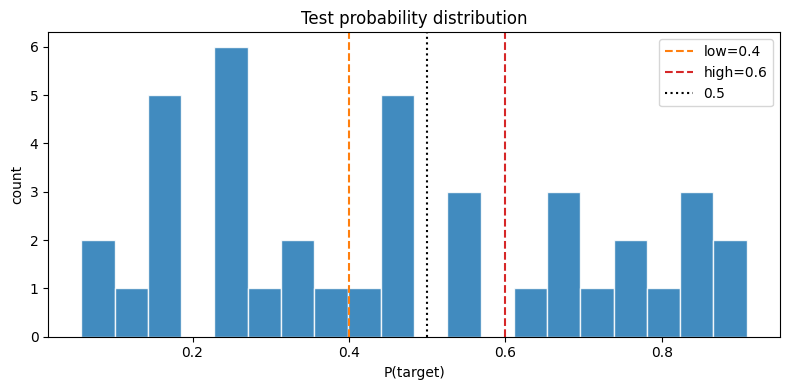

In [21]:
plt.figure(figsize=(8, 4))
plt.hist(proba_test, bins=20, edgecolor="white", alpha=0.85)
plt.axvline(ABSTAIN_LOW, color="C1", linestyle="--", label=f"low={ABSTAIN_LOW}")
plt.axvline(ABSTAIN_HIGH, color="C3", linestyle="--", label=f"high={ABSTAIN_HIGH}")
plt.axvline(0.5, color="black", linestyle=":", label="0.5")
plt.xlabel("P(target)")
plt.ylabel("count")
plt.title("Test probability distribution")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
def binary_metrics(y_true, y_pred):
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


layer_a = binary_metrics(y_test, y_pred_05)

if routed_mask.any():
    layer_b = binary_metrics(y_test[routed_mask], route_pred[routed_mask])
    print("=== Layer B on auto-routed subset ===")
    print(classification_report(
        y_test[routed_mask],
        route_pred[routed_mask],
        target_names=["other", "target"],
    ))
else:
    layer_b = {"precision": np.nan, "recall": np.nan, "f1": np.nan}
    print("No rows auto-routed; widen the band or check probabilities.")

summary = pd.DataFrame(
    [
        {
            "mode": "Layer A always-predict @0.5",
            "coverage": 1.0,
            **layer_a,
        },
        {
            "mode": f"Layer B abstain [{ABSTAIN_LOW}, {ABSTAIN_HIGH}]",
            "coverage": coverage,
            **layer_b,
        },
    ]
)
summary

=== Layer B on auto-routed subset ===
              precision    recall  f1-score   support

       other       1.00      0.90      0.95        20
      target       0.85      1.00      0.92        11

    accuracy                           0.94        31
   macro avg       0.92      0.95      0.93        31
weighted avg       0.95      0.94      0.94        31



,mode,coverage,precision,recall,f1
0,Layer A always-predict @0.5,1.000,0.750000,0.857143,0.800000
1,"Layer B abstain [0.4, 0.6]",0.775,0.846154,1.000000,0.916667


In [23]:
# Abstain slice summary
if abstain_mask.any():
    abstain_df = pd.DataFrame({
        "y_true": y_test[abstain_mask].values,
        "routing_label": df.loc[y_test[abstain_mask].index, "routing_label"].values,
        "p_target": proba_test[abstain_mask],
        "abs_margin": np.abs(proba_test[abstain_mask] - 0.5),
    })
    print("abstain count:", len(abstain_df))
    print("true-label mix among abstains:")
    print(abstain_df["routing_label"].value_counts())
    print("mean |P-0.5| among abstains:", round(abstain_df["abs_margin"].mean(), 4))
    display(abstain_df.sort_values("abs_margin").head(10))
else:
    print("No abstains at this band.")

abstain count: 9
true-label mix among abstains:
routing_label
other     6
target    3
Name: count, dtype: int64
mean |P-0.5| among abstains: 0.0432


,y_true,routing_label,p_target,abs_margin
7,0,other,0.481385,0.018615
2,1,target,0.480196,0.019804
3,1,target,0.527524,0.027524
4,0,other,0.533791,0.033791
5,0,other,0.464622,0.035378
0,0,other,0.546143,0.046143
1,0,other,0.442171,0.057829
8,1,target,0.441727,0.058273
6,0,other,0.408242,0.091758


## 7. Explainability

Global: tokens with largest positive / negative LR coefficients (table + bar chart).

Local: for a few test examples, top tokens by `coef * tfidf` contribution.


,token_target,coef_target,token_other,coef_other
0,cloud,3.734628,services,-2.890806
1,computing,3.479957,rate,-2.653330
2,installation,3.103839,financial,-2.512417
3,kubernetes,3.084990,security,-2.169536
4,latency,2.708243,energy,-2.155981
5,frequency,2.706875,retail,-2.089733
6,portability,2.606155,logistics,-1.975380
7,workload,2.606155,diagnostics,-1.907874
8,compute,2.574076,processspring,-1.643206
9,telecommunications,2.571557,transportation,-1.623063


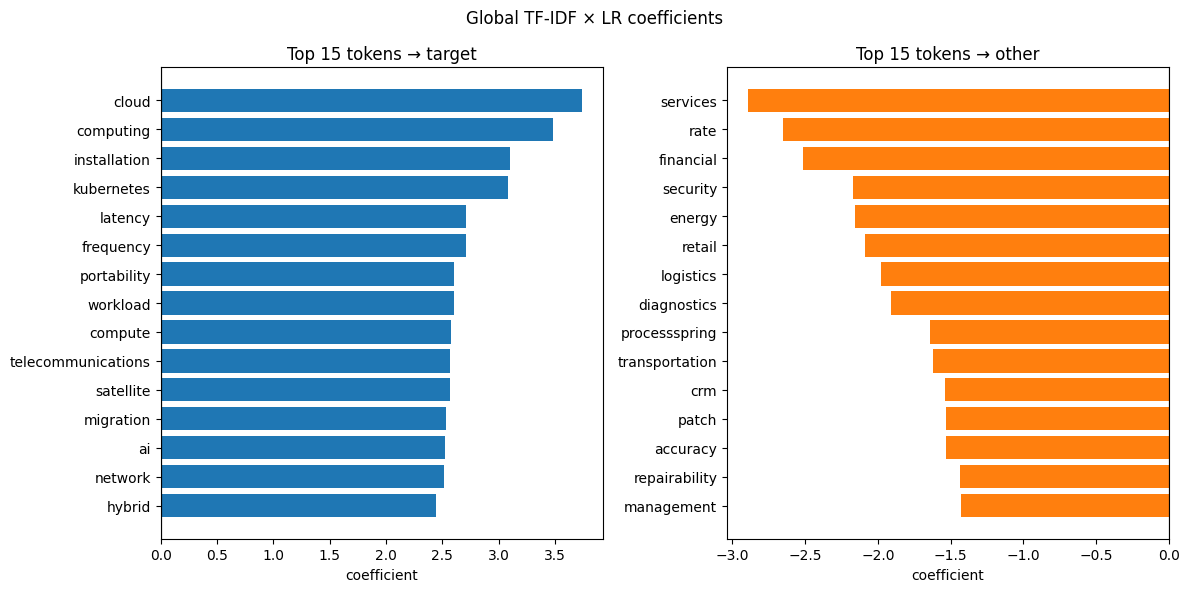

In [89]:
tfidf = best_model.named_steps["tfidf"]
clf = best_model.named_steps["clf"]
feature_names = np.array(tfidf.get_feature_names_out())
coefs = clf.coef_.ravel()

TOP_N = 15
pos_idx = np.argsort(coefs)[-TOP_N:][::-1]
neg_idx = np.argsort(coefs)[:TOP_N]

global_expl = pd.DataFrame({
    "token_target": feature_names[pos_idx],
    "coef_target": coefs[pos_idx],
    "token_other": feature_names[neg_idx],
    "coef_other": coefs[neg_idx],
})
display(global_expl)

# horizontal bar charts: largest |coef| at top of each panel
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=False)

t_tokens = feature_names[pos_idx][::-1]
t_coefs = coefs[pos_idx][::-1]
axes[0].barh(t_tokens, t_coefs, color="C0")
axes[0].set_title(f"Top {TOP_N} tokens → target")
axes[0].set_xlabel("coefficient")
axes[0].axvline(0, color="black", linewidth=0.8)

o_tokens = feature_names[neg_idx][::-1]
o_coefs = coefs[neg_idx][::-1]
axes[1].barh(o_tokens, o_coefs, color="C1")
axes[1].set_title(f"Top {TOP_N} tokens → other")
axes[1].set_xlabel("coefficient")
axes[1].axvline(0, color="black", linewidth=0.8)

fig.suptitle("Global TF-IDF × LR coefficients")
plt.tight_layout()
plt.show()


In [91]:
def local_token_contributions(text: str, top_k: int = 10) -> pd.DataFrame:
    x = tfidf.transform([text])
    contrib = np.asarray(x.multiply(coefs).todense()).ravel()
    nz = np.flatnonzero(x.toarray().ravel())
    order = nz[np.argsort(np.abs(contrib[nz]))[::-1][:top_k]]
    return pd.DataFrame({
        "token": feature_names[order],
        "tfidf": x.toarray().ravel()[order],
        "coef": coefs[order],
        "contribution": contrib[order],
    })


# Pick examples: 1 correct target, 1 correct other, 1 abstain (if any)
test_index = X_test.index.to_numpy()
examples = []

correct_target = np.where((y_test.values == 1) & (y_pred_05 == 1))[0]
correct_other = np.where((y_test.values == 0) & (y_pred_05 == 0))[0]
abstain_idx = np.where(abstain_mask)[0]

if len(correct_target):
    examples.append(("correct target", int(correct_target[0])))
if len(correct_other):
    examples.append(("correct other", int(correct_other[0])))
if len(abstain_idx):
    examples.append(("abstain", int(abstain_idx[0])))

for label, i in examples:
    row_id = test_index[i]
    text = X_test.iloc[i]
    print("=" * 60)
    print(f"{label} | article_id={df.loc[row_id, 'article_id']} | "
          f"true={df.loc[row_id, 'routing_label']} | P(target)={proba_test[i]:.3f}")
    print("title:", df.loc[row_id, "title"][:120])
    display(local_token_contributions(text))
    print()

correct target | article_id=V4-0039 | true=target | P(target)=0.760
title: Hybrid Cloud Investment Accelerates in Australia


,token,tfidf,coef,contribution
0,cloud,0.146862,3.734628,0.548476
1,computing,0.134426,3.479957,0.467796
2,frequency,0.134111,2.706875,0.363021
3,hybrid,0.140803,2.444687,0.344219
4,network,0.070287,2.510454,0.176452
5,cybersecurity,0.078442,1.965785,0.154200
6,security,0.070287,-2.169536,-0.152490
7,speed,0.066914,1.405118,0.094022
8,connectivity,0.073288,1.269419,0.093033
9,service,0.060607,1.035115,0.062735



correct other | article_id=V4-0117 | true=other | P(target)=0.140
title: Operators Rethink the Economics of Camera Systems


,token,tfidf,coef,contribution
0,device,0.276360,-1.111887,-0.307281
1,weight,0.276360,-1.111887,-0.307281
2,speed,0.073090,1.405118,0.102700
3,service,0.066201,1.035115,0.068526
4,camera,0.163222,-0.395410,-0.064540
5,as,0.084223,0.734043,0.061823
6,showed,0.083696,-0.647342,-0.054180
7,will,0.095490,-0.416360,-0.039758
8,can,0.084750,0.417651,0.035396
9,is,0.049695,-0.699807,-0.034777



abstain | article_id=V4-0108 | true=other | P(target)=0.546
title: RelayWorks Expands Workflow Automation Program


,token,tfidf,coef,contribution
0,cloud,0.107388,3.734628,0.401053
1,computing,0.089471,3.479957,0.311357
2,network,0.079208,2.510454,0.198849
3,security,0.079208,-2.169536,-0.171845
4,software,0.189334,0.583298,0.110438
5,connectivity,0.082591,1.269419,0.104842
6,automation,0.168397,-0.621275,-0.104621
7,workflow,0.168397,-0.621275,-0.104621
8,ontario,0.182100,-0.566102,-0.103087
9,enterprise,0.193027,0.504452,0.097373


## Save trained model

Saves the GridSearchCV-selected TF-IDF + LR pipeline.

Artifact → `models/ml_binary_v1.joblib` (next to `data/`).


In [64]:
import joblib

MODELS_DIR = DATA_PATH.parent / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODELS_DIR / "ml_binary_v1.joblib"

joblib.dump(best_model, MODEL_PATH)
print("saved:", MODEL_PATH.resolve())
print("reload example: loaded = joblib.load(MODEL_PATH)")


saved: /Users/jianchenyang/Documents/projects/file_topic_routing/data/models/ml_binary_v1.joblib
reload example: loaded = joblib.load(MODEL_PATH)


## Notes / next steps

Broader roadmap beyond this TF-IDF + LR baseline (not a single-version dump — sequence by impact and risk).

### 1. Data & labels
- Grow data size; improve label quality / guidelines for `target` vs `other`
- Label QA and hard negatives; check synth template leakage
- Optional text augmentation (paraphrase) — secondary to more real/diverse articles
- Stress-test synth → real articles when real data is available
- Human-in-the-loop on abstains to feed new labeled data

### 2. Representations (important upgrade path)
- **TF-IDF (current)** → **pretrained text embeddings** (e.g. sentence-transformers) with a frozen encoder + linear/MLP head
- Later: fine-tune an encoder or stronger generative classifiers if frozen embeddings plateau
- **Text preprocessing for the bag-of-words / TF-IDF path:** lemmatization (or stemming), optional stopword handling, light normalization — compare vs current default tokenizer via CV; usually less necessary once you switch to pretrained embeddings (their tokenizers already normalize)
- Smaller side paths: char n-grams, hashing tricks, SVD/NMF on TF-IDF
- Expect explainability tooling to change once you leave linear TF-IDF space

### 3. Features
- Add `title` and selected metadata (`publication_type`, `article_length`, etc.) with leakage checks (synth rules may proxy the label)
- Combine text embeddings/TF-IDF with metadata in one pipeline

### 4. Models
- Classifier bake-off + hyperparameter tuning (after the representation baseline is clear)
- **Iterative hyperparam refinement from GridSearchCV diagnostics:** use the ranked CV scores / heatmaps to tighten or expand the grid around promising regions (e.g. denser `C` near the winner, revisit `max_features` / n-grams) — still train/CV only; do not retune from test metrics
- Prefer comparing a few diverse models fairly before stacking
- Stacking / meta-learner only when data is large enough for a clean meta holdout (often later than n≈200)

### 5. Decisioning (threshold & confidence)
- Properly tune the decision threshold on train only (inner val or CV / nested selection for F1, Youden, etc.); keep test one-shot — do not pick `t` from test analytics
- Tune the Layer B abstain band on train/val only. Current `[0.4, 0.6]` is illustrative. Options:
  - Symmetric margin `m` → `[0.5-m, 0.5+m]` (notebook uses `m=0.1`)
  - Coverage target (e.g. auto-route ≥70%)
  - Precision / routed-F1 floor on validation
  - Asymmetric band if false Target is costlier than false Other
- Probability calibration if bands/thresholds look unstable — especially after switching to embeddings
- More advanced selective prediction / coverage–precision curves

### 6. Evaluation & methodology
- Slice metrics (by `topic`, length, difficulty); learning curves (does more data help?)
- Nested CV for honest claims when tuning model + threshold + band
- Cost-sensitive metrics aligned with routing FP vs FN

### 7. Explainability & error analysis
- Richer local explanations beyond coef × tfidf (and embedding-appropriate methods later)
- Systematic error taxonomy: false Target / false Other / abstain → drive data and feature fixes

### 8. Productization
- Versioned model + featurizer artifact; batch/API inference
- Monitor score drift, abstain rate drift
- Reviewer workflow for abstains

### Out of scope until earlier steps pay off
- Full multi-model zoo or stacking on tiny n
- Heavy transformer fine-tuning before trying frozen pretrained embeddings
- Picking thresholds/bands on the test set
